# Week 3 - Baseline CNN Training

Goals:
1. Load Week 2 metadata and pipeline config.
2. Build train/val/test dataloaders.
3. Define a small baseline CNN.
4. Train with CrossEntropyLoss + AdamW.
5. Save checkpoints, curves, and metrics.
6. Inspect validation errors.

In [21]:
import os
import json
import time
import math
import random
import pathlib
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import GTSRB

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report
)

try:
    from tqdm.auto import tqdm
except ImportError:
    !pip -q install tqdm
    from tqdm.auto import tqdm

In [22]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


In [23]:
PROJECT_ROOT = pathlib.Path("/content/traffic-sign-classification")
REPORT_ROOT = PROJECT_ROOT / "reports" / "week3"
META_ROOT = PROJECT_ROOT / "artifacts" / "metadata"
DATA_ROOT = PROJECT_ROOT / "data"
CHECKPOINT_ROOT = pathlib.Path("/content/checkpoints")

for p in [DATA_ROOT, REPORT_ROOT, META_ROOT, CHECKPOINT_ROOT]:
    p.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("REPORT_ROOT:", REPORT_ROOT)
print("CHECKPOINT_ROOT:", CHECKPOINT_ROOT)

PROJECT_ROOT: /content/traffic-sign-classification
REPORT_ROOT: /content/traffic-sign-classification/reports/week3
CHECKPOINT_ROOT: /content/checkpoints


In [24]:
tv_train = GTSRB(root=str(DATA_ROOT), split="train", download=True)
tv_test = GTSRB(root=str(DATA_ROOT), split="test", download=True)

print("Torchvision train size:", len(tv_train))
print("Torchvision test size:", len(tv_test))

100%|██████████| 187M/187M [00:12<00:00, 15.0MB/s]
100%|██████████| 89.0M/89.0M [00:06<00:00, 14.4MB/s]
100%|██████████| 99.6k/99.6k [00:00<00:00, 197kB/s]


Torchvision train size: 26640
Torchvision test size: 12630


In [25]:
train_df = pd.read_csv(META_ROOT / "train_metadata_full.csv")
test_df = pd.read_csv(META_ROOT / "test_metadata_full.csv")

with open(META_ROOT / "week2_pipeline_config.json", "r") as f:
    pipeline_config = json.load(f)

train_meta = train_df[train_df["split"] == "train"].reset_index(drop=True)
val_meta = train_df[train_df["split"] == "val"].reset_index(drop=True)

print("Train rows:", len(train_meta))
print("Val rows:", len(val_meta))
print("Test rows:", len(test_df))
print(json.dumps(pipeline_config, indent=2))

Train rows: 23976
Val rows: 2664
Test rows: 12630
{
  "seed": 42,
  "image_size": 64,
  "batch_size": 128,
  "use_roi_crop": true,
  "preprocessing": "clahe",
  "pad_ratio": 0.08,
  "mean": [
    0.48077961802482605,
    0.4455212652683258,
    0.45868155360221863
  ],
  "std": [
    0.2539152204990387,
    0.2469169795513153,
    0.25597625970840454
  ]
}


In [26]:
import sys
sys.path.append(str(PROJECT_ROOT))

from src.datasets import GTSRBCustomDataset

In [27]:
NUM_CLASSES = 43
IMG_SIZE = int(pipeline_config["image_size"])
MEAN = pipeline_config["mean"]
STD = pipeline_config["std"]

USE_ROI_CROP = bool(pipeline_config["use_roi_crop"])
PREPROCESSING = pipeline_config["preprocessing"]
PAD_RATIO = float(pipeline_config["pad_ratio"])

BATCH_SIZE = 128
NUM_EPOCHS = 15
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
EARLY_STOPPING_PATIENCE = 5

print("IMG_SIZE:", IMG_SIZE)
print("PREPROCESSING:", PREPROCESSING)

IMG_SIZE: 64
PREPROCESSING: clahe


In [28]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomAffine(
        degrees=10,
        translate=(0.10, 0.10),
        scale=(0.9, 1.1)
    ),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD)
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD)
])

In [29]:
train_ds = GTSRBCustomDataset(
    train_meta,
    transform=train_transform,
    use_roi_crop=USE_ROI_CROP,
    preprocessing=PREPROCESSING,
    pad_ratio=PAD_RATIO
)

val_ds = GTSRBCustomDataset(
    val_meta,
    transform=eval_transform,
    use_roi_crop=USE_ROI_CROP,
    preprocessing=PREPROCESSING,
    pad_ratio=PAD_RATIO
)

test_ds = GTSRBCustomDataset(
    test_df,
    transform=eval_transform,
    use_roi_crop=USE_ROI_CROP,
    preprocessing=PREPROCESSING,
    pad_ratio=PAD_RATIO
)

print(len(train_ds), len(val_ds), len(test_ds))

23976 2664 12630


In [30]:
train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 188
Val batches: 21
Test batches: 99


In [31]:
x, y = next(iter(train_loader))
print("x shape:", x.shape)
print("y shape:", y.shape)
print("label range:", int(y.min()), int(y.max()))

x shape: torch.Size([128, 3, 64, 64])
y shape: torch.Size([128])
label range: 1 42


In [32]:
class BaselineCNN(nn.Module):
    def __init__(self, num_classes=43):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2)
        )

        self.pool = nn.AdaptiveAvgPool2d((1, 1))

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.30),
            nn.Linear(256, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.30),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = self.classifier(x)
        return x

In [33]:
model = BaselineCNN(num_classes=NUM_CLASSES).to(DEVICE)

dummy = torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
with torch.no_grad():
    out = model(dummy)

print(model)
print("Output shape:", out.shape)

BaselineCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, 

In [34]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2
)

In [35]:
def compute_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    return {
        "accuracy": float(acc),
        "precision_macro": float(precision),
        "recall_macro": float(recall),
        "f1_macro": float(f1)
    }

In [36]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    all_preds = []
    all_targets = []

    for images, targets in tqdm(loader, leave=False):
        images = images.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)

        optimizer.zero_grad()

        logits = model(images)
        loss = criterion(logits, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        preds = logits.argmax(dim=1)
        all_preds.extend(preds.detach().cpu().numpy().tolist())
        all_targets.extend(targets.detach().cpu().numpy().tolist())

    epoch_loss = running_loss / len(loader.dataset)
    metrics = compute_metrics(all_targets, all_preds)
    return epoch_loss, metrics

In [37]:
@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    all_preds = []
    all_targets = []

    for images, targets in tqdm(loader, leave=False):
        images = images.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)

        logits = model(images)
        loss = criterion(logits, targets)

        running_loss += loss.item() * images.size(0)

        preds = logits.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy().tolist())
        all_targets.extend(targets.cpu().numpy().tolist())

    epoch_loss = running_loss / len(loader.dataset)
    metrics = compute_metrics(all_targets, all_preds)
    return epoch_loss, metrics, np.array(all_targets), np.array(all_preds)

In [38]:
def save_checkpoint(path, model, optimizer, epoch, history, best_score):
    torch.save({
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "history": history,
        "best_score": best_score
    }, path)

In [39]:
history = []

best_val_f1 = -1.0
best_epoch = -1
patience_counter = 0

best_ckpt_path = CHECKPOINT_ROOT / "baseline_cnn_best.pth"
last_ckpt_path = CHECKPOINT_ROOT / "baseline_cnn_last.pth"

for epoch in range(1, NUM_EPOCHS + 1):
    start_time = time.time()

    train_loss, train_metrics = train_one_epoch(
        model, train_loader, criterion, optimizer, DEVICE
    )

    val_loss, val_metrics, y_val_true, y_val_pred = evaluate(
        model, val_loader, criterion, DEVICE
    )

    scheduler.step(val_metrics["f1_macro"])

    epoch_time = time.time() - start_time
    lr_now = optimizer.param_groups[0]["lr"]

    row = {
        "epoch": epoch,
        "lr": lr_now,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "train_accuracy": train_metrics["accuracy"],
        "train_precision_macro": train_metrics["precision_macro"],
        "train_recall_macro": train_metrics["recall_macro"],
        "train_f1_macro": train_metrics["f1_macro"],
        "val_accuracy": val_metrics["accuracy"],
        "val_precision_macro": val_metrics["precision_macro"],
        "val_recall_macro": val_metrics["recall_macro"],
        "val_f1_macro": val_metrics["f1_macro"],
        "epoch_time_sec": epoch_time
    }
    history.append(row)

    print(
        f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
        f"train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | "
        f"train_acc={train_metrics['accuracy']:.4f} | val_acc={val_metrics['accuracy']:.4f} | "
        f"val_f1={val_metrics['f1_macro']:.4f} | lr={lr_now:.6f}"
    )

    save_checkpoint(last_ckpt_path, model, optimizer, epoch, history, best_val_f1)

    if val_metrics["f1_macro"] > best_val_f1:
        best_val_f1 = val_metrics["f1_macro"]
        best_epoch = epoch
        patience_counter = 0
        save_checkpoint(best_ckpt_path, model, optimizer, epoch, history, best_val_f1)
        print(f"Saved new best checkpoint at epoch {epoch}.")
    else:
        patience_counter += 1
        print(f"No improvement. Patience: {patience_counter}/{EARLY_STOPPING_PATIENCE}")

    if patience_counter >= EARLY_STOPPING_PATIENCE:
        print("Early stopping triggered.")
        break

  0%|          | 0/188 [00:00<?, ?it/s]

  0%|          | 0/21 [00:00<?, ?it/s]

Epoch 01/15 | train_loss=2.2276 | val_loss=1.2499 | train_acc=0.3362 | val_acc=0.6107 | val_f1=0.3770 | lr=0.001000
Saved new best checkpoint at epoch 1.


  0%|          | 0/188 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x78d156363240>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x78d156363240>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

...

  0%|          | 0/188 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x78d156363240>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x78d156363240>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

  0%|          | 0/21 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x78d156363240>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x78d156363240>    
if w.is_alive():Traceback (most recent call last):

  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
      self._shutdown_workers()  
   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
      if w.is_alive():
^^ ^ ^ ^ ^  ^ ^^^^^^^^^^^
^  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
^    assert self._parent_pid == os.getpid(), 'can only test a child process'^
^   ^^ 
   File "/usr/lib/p

Epoch 15/15 | train_loss=0.0733 | val_loss=0.0173 | train_acc=0.9773 | val_acc=0.9951 | val_f1=0.9931 | lr=0.001000
Saved new best checkpoint at epoch 15.


In [40]:
history_df = pd.DataFrame(history)
history_csv_path = REPORT_ROOT / "baseline_history.csv"
history_df.to_csv(history_csv_path, index=False)

print(history_df.tail())
print("Saved:", history_csv_path)

    epoch     lr  train_loss  val_loss  train_accuracy  train_precision_macro  \
10     11  0.001    0.098176  0.238440        0.970012               0.961799   
11     12  0.001    0.083336  0.046228        0.972556               0.966239   
12     13  0.001    0.092260  0.036980        0.970637               0.962127   
13     14  0.001    0.075557  0.111854        0.976226               0.971085   
14     15  0.001    0.073292  0.017271        0.977311               0.972504   

    train_recall_macro  train_f1_macro  val_accuracy  val_precision_macro  \
10            0.959076        0.960330      0.930931             0.941746   
11            0.963051        0.964604      0.985736             0.986384   
12            0.960582        0.961313      0.989114             0.989103   
13            0.968631        0.969794      0.970345             0.966599   
14            0.971095        0.971780      0.995120             0.993302   

    val_recall_macro  val_f1_macro  epoch_time_sec

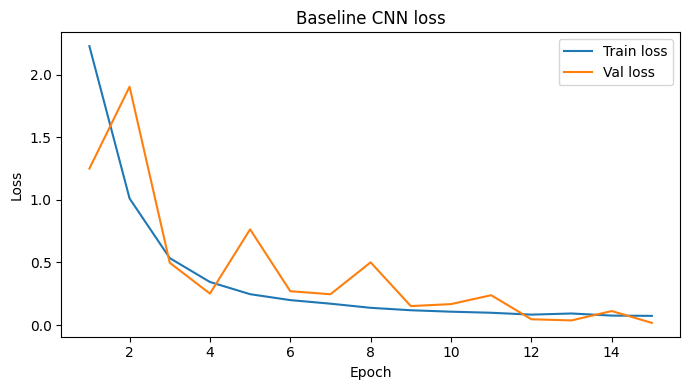

Saved: /content/traffic-sign-classification/reports/week3/baseline_loss_curve.png


In [41]:
plt.figure(figsize=(7, 4))
plt.plot(history_df["epoch"], history_df["train_loss"], label="Train loss")
plt.plot(history_df["epoch"], history_df["val_loss"], label="Val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline CNN loss")
plt.legend()
plt.tight_layout()

loss_plot_path = REPORT_ROOT / "baseline_loss_curve.png"
plt.savefig(loss_plot_path, dpi=200)
plt.show()

print("Saved:", loss_plot_path)

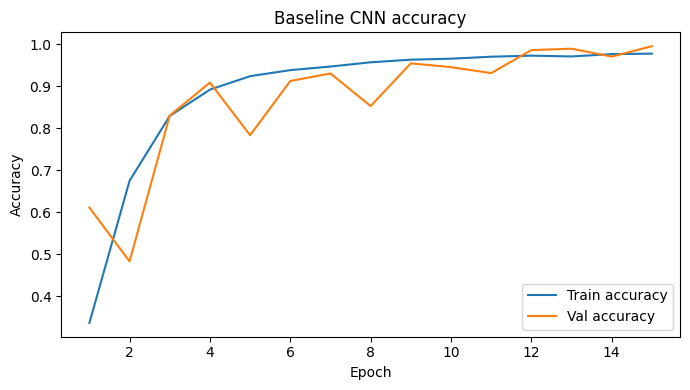

Saved: /content/traffic-sign-classification/reports/week3/baseline_accuracy_curve.png


In [42]:
plt.figure(figsize=(7, 4))
plt.plot(history_df["epoch"], history_df["train_accuracy"], label="Train accuracy")
plt.plot(history_df["epoch"], history_df["val_accuracy"], label="Val accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Baseline CNN accuracy")
plt.legend()
plt.tight_layout()

acc_plot_path = REPORT_ROOT / "baseline_accuracy_curve.png"
plt.savefig(acc_plot_path, dpi=200)
plt.show()

print("Saved:", acc_plot_path)

In [43]:
ckpt = torch.load(best_ckpt_path, map_location=DEVICE)
model.load_state_dict(ckpt["model_state_dict"])

print("Loaded best checkpoint from epoch:", ckpt["epoch"])
print("Best val F1:", ckpt["best_score"])

Loaded best checkpoint from epoch: 15
Best val F1: 0.9931197804253508


In [44]:
val_loss, val_metrics, y_val_true, y_val_pred = evaluate(
    model, val_loader, criterion, DEVICE
)

print("Validation loss:", val_loss)
print(json.dumps(val_metrics, indent=2))

  0%|          | 0/21 [00:00<?, ?it/s]

Validation loss: 0.01727094504543141
{
  "accuracy": 0.9951201201201201,
  "precision_macro": 0.9933024382597301,
  "recall_macro": 0.9933840294789905,
  "f1_macro": 0.9931197804253508
}


In [45]:
report_dict = classification_report(
    y_val_true,
    y_val_pred,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report_dict).transpose()
report_df.head()

,precision,recall,f1-score,support
0,1.000000,1.000000,1.000000,15.0
1,0.993377,1.000000,0.996678,150.0
2,0.993377,1.000000,0.996678,150.0
3,0.989583,0.989583,0.989583,96.0
4,0.992424,0.992424,0.992424,132.0


In [46]:
metrics_payload = {
    "best_epoch": int(ckpt["epoch"]),
    "val_loss": float(val_loss),
    "val_metrics": val_metrics
}

metrics_json_path = REPORT_ROOT / "baseline_metrics.json"
with open(metrics_json_path, "w") as f:
    json.dump(metrics_payload, f, indent=2)

report_csv_path = REPORT_ROOT / "baseline_classification_report.csv"
report_df.to_csv(report_csv_path, index=True)

print("Saved:", metrics_json_path)
print("Saved:", report_csv_path)

Saved: /content/traffic-sign-classification/reports/week3/baseline_metrics.json
Saved: /content/traffic-sign-classification/reports/week3/baseline_classification_report.csv


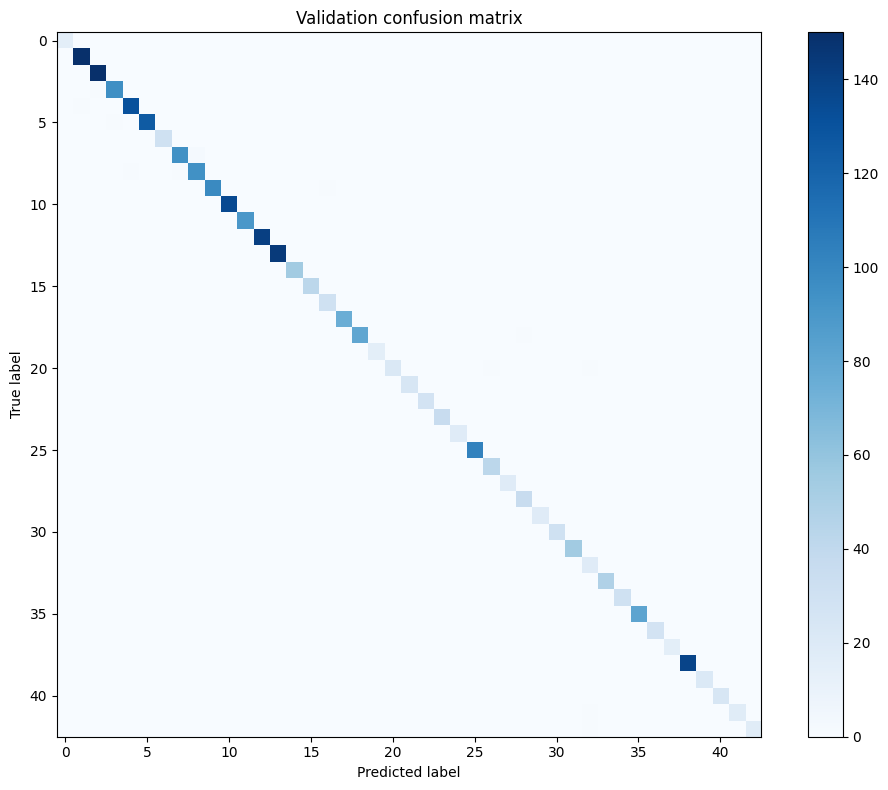

Saved: /content/traffic-sign-classification/reports/week3/baseline_confusion_matrix.png


In [47]:
cm = confusion_matrix(y_val_true, y_val_pred, labels=list(range(NUM_CLASSES)))

plt.figure(figsize=(10, 8))
plt.imshow(cm, interpolation="nearest", cmap="Blues")
plt.title("Validation confusion matrix")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.colorbar()
plt.tight_layout()

cm_path = REPORT_ROOT / "baseline_confusion_matrix.png"
plt.savefig(cm_path, dpi=200)
plt.show()

print("Saved:", cm_path)

In [48]:
def denormalize(x, mean, std):
    mean = torch.tensor(mean).view(3, 1, 1)
    std = torch.tensor(std).view(3, 1, 1)
    return (x * std + mean).clamp(0, 1)

In [49]:
@torch.no_grad()
def collect_misclassified_samples(model, dataset, device, max_items=12):
    model.eval()
    items = []

    for idx in range(len(dataset)):
        image, label = dataset[idx]
        logits = model(image.unsqueeze(0).to(device))
        pred = int(logits.argmax(dim=1).item())

        if pred != label:
            items.append((image.cpu(), int(label), pred))
            if len(items) >= max_items:
                break

    return items

misclassified = collect_misclassified_samples(model, val_ds, DEVICE, max_items=12)
print("Collected misclassified samples:", len(misclassified))

Collected misclassified samples: 12


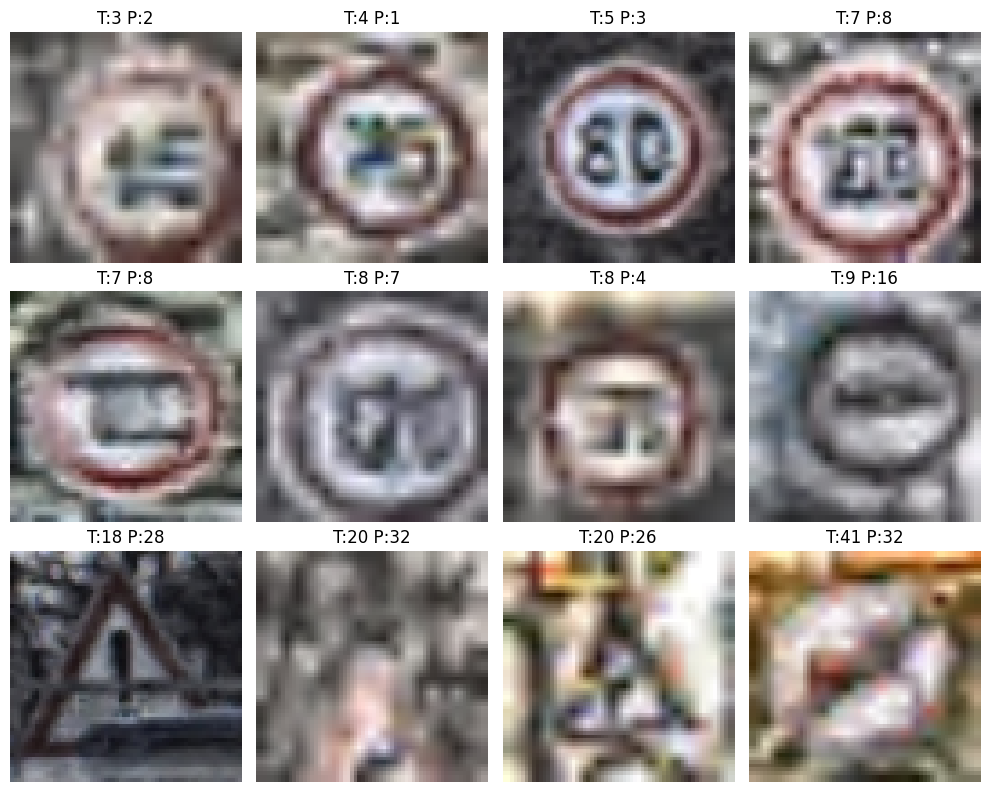

Saved: /content/traffic-sign-classification/reports/week3/baseline_misclassified_samples.png


In [50]:
fig, axes = plt.subplots(3, 4, figsize=(10, 8))
axes = axes.flatten()

for ax in axes:
    ax.axis("off")

for ax, (img, true_label, pred_label) in zip(axes, misclassified):
    img = denormalize(img, MEAN, STD).permute(1, 2, 0).numpy()
    ax.imshow(img)
    ax.set_title(f"T:{true_label} P:{pred_label}")
    ax.axis("off")

plt.tight_layout()
mis_path = REPORT_ROOT / "baseline_misclassified_samples.png"
plt.savefig(mis_path, dpi=200)
plt.show()

print("Saved:", mis_path)

In [52]:
# Rebuild test_df with robust column normalization
import pandas as pd
from torch.utils.data import DataLoader

gtsrb_root = DATA_ROOT / "gtsrb"
test_csv = gtsrb_root / "GT-final_test.csv"
test_img_dir = gtsrb_root / "GTSRB" / "Final_Test" / "Images"

test_df = pd.read_csv(test_csv, sep=";")

# Map possible ROI column name variants to the lowercase names expected by src.datasets.py
rename_map = {}
for col in test_df.columns:
    c = col.strip().lower()
    if c == "filename":
        rename_map[col] = "filename"
    elif c == "width":
        rename_map[col] = "width"
    elif c == "height":
        rename_map[col] = "height"
    elif c in ["roi.x1", "roi_x1"]:
        rename_map[col] = "roi_x1"
    elif c in ["roi.y1", "roi_y1"]:
        rename_map[col] = "roi_y1"
    elif c in ["roi.x2", "roi_x2"]:
        rename_map[col] = "roi_x2"
    elif c in ["roi.y2", "roi_y2"]:
        rename_map[col] = "roi_y2"
    elif c == "classid":
        rename_map[col] = "label"

test_df = test_df.rename(columns=rename_map)
test_df["image_path"] = test_df["filename"].apply(lambda x: str((test_img_dir / x).resolve()))
test_df["split"] = "test"

required_cols = ["image_path", "label", "roi_x1", "roi_y1", "roi_x2", "roi_y2"]
missing = [c for c in required_cols if c not in test_df.columns]
print("Missing columns:", missing)

# Rebuild test dataset and loader
test_ds = GTSRBCustomDataset(
    test_df,
    transform=eval_transform,
    use_roi_crop=USE_ROI_CROP,
    preprocessing=PREPROCESSING,
    pad_ratio=PAD_RATIO
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

# Evaluate
test_loss, test_metrics, y_test_true, y_test_pred = evaluate(
    model, test_loader, criterion, DEVICE
)

print("Test loss:", test_loss)
print(json.dumps(test_metrics, indent=2))

Missing columns: []


  0%|          | 0/99 [00:00<?, ?it/s]

Test loss: 0.1447592919779409
{
  "accuracy": 0.9661124307205067,
  "precision_macro": 0.9419970785626723,
  "recall_macro": 0.9483500949860908,
  "f1_macro": 0.9409898039666634
}


In [53]:
test_metrics_path = REPORT_ROOT / "baseline_test_metrics.json"
with open(test_metrics_path, "w") as f:
    json.dump({
        "test_loss": float(test_loss),
        "test_metrics": test_metrics
    }, f, indent=2)

print("Saved:", test_metrics_path)

Saved: /content/traffic-sign-classification/reports/week3/baseline_test_metrics.json
